# Model Preparation

## Objective

The objective of this stage is to prepare the engineered weekly sales data for machine learning.

We will:

* Select relevant forecasting features.
* Separate training and testing data chronologically.
* Avoid data leakage by ensuring that future observations are not used to train the model.


## Loading the feature dataset

In [1]:
import pandas as pd
import numpy as np

sales = pd.read_csv("../data/sales_daily.csv")

sales["Date"] = pd.to_datetime(sales["Date"])

weekly_sales = (
    sales.set_index("Date")
    .groupby("SKU")["Units_Sold"]
    .resample("W")
    .sum()
    .reset_index()
)

weekly_complete = weekly_sales[
    weekly_sales["Date"] < "2026-01-04"
].copy()

print(weekly_complete.shape)

(5200, 3)


## Creating forecasting features

In [2]:
weekly_complete["lag_1"] = (
    weekly_complete.groupby("SKU")["Units_Sold"].shift(1)
)

weekly_complete["lag_4"] = (
    weekly_complete.groupby("SKU")["Units_Sold"].shift(4)
)

weekly_complete["rolling_mean_4"] = (
    weekly_complete.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

weekly_complete["rolling_std_4"] = (
    weekly_complete.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=4).std())
)

weekly_complete["rolling_max_4"] = (
    weekly_complete.groupby("SKU")["Units_Sold"]
    .transform(lambda x: x.shift(1).rolling(window=4).max())
)

weekly_complete["lag_52"] = (
    weekly_complete.groupby("SKU")["Units_Sold"].shift(52)
)

print(weekly_complete.shape)

(5200, 9)


## Removing rows with missing feature values

In [3]:
feature_data = weekly_complete.dropna().copy()

print("Original data:", weekly_complete.shape)
print("Cleaned data:", feature_data.shape)
print("Missing values:")
print(feature_data.isnull().sum())

Original data: (5200, 9)
Cleaned data: (2600, 9)
Missing values:
SKU               0
Date              0
Units_Sold        0
lag_1             0
lag_4             0
rolling_mean_4    0
rolling_std_4     0
rolling_max_4     0
lag_52            0
dtype: int64


In [4]:
print("First date:", feature_data["Date"].min())
print("Last date:", feature_data["Date"].max())

print("\nRecords per SKU:")
print(feature_data.groupby("SKU").size().head())

First date: 2025-01-05 00:00:00
Last date: 2025-12-28 00:00:00

Records per SKU:
SKU
SKU001    52
SKU002    52
SKU003    52
SKU004    52
SKU005    52
dtype: int64


## Creating chronological train-test split

In [5]:
split_date = pd.Timestamp("2025-10-05")

train_data = feature_data[
    feature_data["Date"] < split_date
].copy()

test_data = feature_data[
    feature_data["Date"] >= split_date
].copy()

print("Training shape:", train_data.shape)
print("Testing shape:", test_data.shape)

print("\nTraining date range:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTesting date range:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Training shape: (1950, 9)
Testing shape: (650, 9)

Training date range:
2025-01-05 00:00:00 to 2025-09-28 00:00:00

Testing date range:
2025-10-05 00:00:00 to 2025-12-28 00:00:00


In [6]:
split_date = pd.Timestamp("2025-10-12")

train_data = feature_data[
    feature_data["Date"] < split_date
].copy()

test_data = feature_data[
    feature_data["Date"] >= split_date
].copy()

print("Training shape:", train_data.shape)
print("Testing shape:", test_data.shape)

print("\nTraining dates:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTesting dates:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

Training shape: (2000, 9)
Testing shape: (600, 9)

Training dates:
2025-01-05 00:00:00 to 2025-10-05 00:00:00

Testing dates:
2025-10-12 00:00:00 to 2025-12-28 00:00:00


## Selecting Features and Target

In [7]:
features = [
    "lag_1",
    "lag_4",
    "rolling_mean_4",
    "rolling_std_4",
    "rolling_max_4",
    "lag_52"
]

target = "Units_Sold"

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2000, 6)
y_train: (2000,)
X_test: (600, 6)
y_test: (600,)


## Model Preparation – Final Findings

### Dataset Preparation

* Original weekly dataset: 5,200 records.
* Engineered features: 6.
* Missing feature values were removed.
* Final feature dataset: 2,600 records across 50 SKUs.

### Chronological Train-Test Split

* Training records: 2,000.
* Testing records: 600.
* Training period: January 5, 2025 to October 5, 2025.
* Testing period: October 12, 2025 to December 28, 2025.

### Input Features

* `lag_1`
* `lag_4`
* `rolling_mean_4`
* `rolling_std_4`
* `rolling_max_4`
* `lag_52`

### Target Variable

`Units_Sold` represents weekly product demand.

### Final Shapes

* X_train: (2000, 6)
* y_train: (2000,)
* X_test: (600, 6)
* y_test: (600,)

### Conclusion

The data has been prepared for machine learning using a chronological split to preserve the time order of observations.


# Model Training

## Random Forest Regressor

In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

print(model)

RandomForestRegressor(random_state=42)


## Train the model

In [9]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## Model Predictions

In [10]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[75.61 86.79 83.79 81.46 89.64 82.49 83.22 80.93 74.09 86.94]


## Comparing actual vs predicted sales

In [11]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0      82      75.61
1      82      86.79
2      78      83.79
3      93      81.46
4      92      89.64
5      87      82.49
6      84      83.22
7      84      80.93
8      88      74.09
9      89      86.94


## Model Evaluation – MAE

In [13]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 8.455866666666667


In [14]:
from sklearn.metrics import mean_absolute_error

wape = np.sum(np.abs(y_test.values - y_pred)) / np.sum(y_test.values) * 100

print("WAPE:", wape, "%")

WAPE: 10.041006966434454 %


## Compare with Seasonal Naive

In [15]:
seasonal_pred = X_test["lag_52"].values

seasonal_mae = mean_absolute_error(y_test, seasonal_pred)

seasonal_wape = (
    np.sum(np.abs(y_test.values - seasonal_pred))
    / np.sum(y_test.values)
) * 100

print("Seasonal Naive MAE:", seasonal_mae)
print("Seasonal Naive WAPE:", seasonal_wape, "%")

Seasonal Naive MAE: 9.691666666666666
Seasonal Naive WAPE: 11.508470550981635 %


In [16]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Seasonal Naive"],
    "MAE": [mae, seasonal_mae],
    "WAPE (%)": [wape, seasonal_wape]
})

print(results)

            Model       MAE   WAPE (%)
0   Random Forest  8.455867  10.041007
1  Seasonal Naive  9.691667  11.508471


## Plot MAE comparison

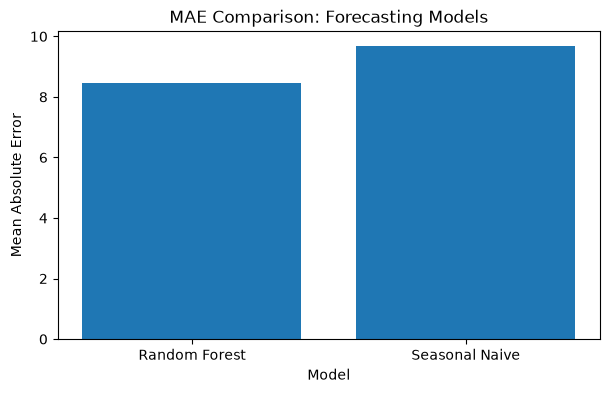

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(results["Model"], results["MAE"])

plt.title("MAE Comparison: Forecasting Models")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.show()

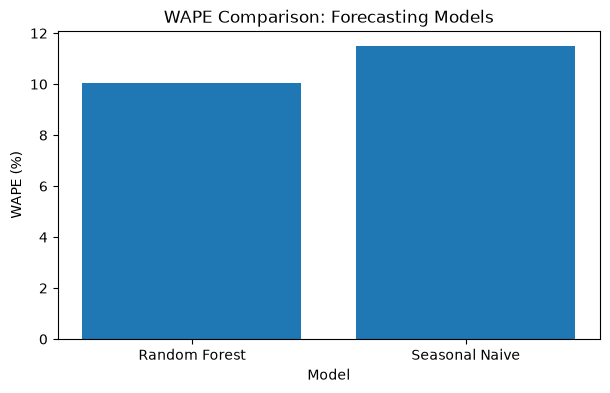

In [18]:
plt.figure(figsize=(7, 4))

plt.bar(results["Model"], results["WAPE (%)"])

plt.title("WAPE Comparison: Forecasting Models")
plt.xlabel("Model")
plt.ylabel("WAPE (%)")

plt.show()

## Model Evaluation and Baseline Comparison

### Models Evaluated

* Random Forest Regressor
* Seasonal Naive Baseline

### Evaluation Metrics

| Model          |  MAE |   WAPE |
| -------------- | ---: | -----: |
| Random Forest  | 8.46 | 10.04% |
| Seasonal Naive | 9.69 | 11.51% |

### Key Findings

* Random Forest achieved a lower MAE and WAPE than the Seasonal Naive baseline on the current test set.
* The Random Forest model's average absolute prediction error was approximately 8.46 units.
* Its WAPE was 10.04%.
* These are initial rolling one-week-ahead evaluation results, not a fixed 12-week-ahead forecast.
* Further rolling-origin backtesting is required to evaluate forecasting performance consistently across time.

### Conclusion

The initial results show that Random Forest can capture useful patterns in weekly product demand. Its performance will be assessed further using a consistent rolling-origin backtest before selecting it for deployment.


In [19]:
prediction_results = test_data[["SKU", "Date", "Units_Sold"]].copy()

prediction_results["Random_Forest_Forecast"] = y_pred
prediction_results["Seasonal_Naive_Forecast"] = seasonal_pred

prediction_results.head(10)

,SKU,Date,Units_Sold,Random_Forest_Forecast,Seasonal_Naive_Forecast
92,SKU001,2025-10-12,82,75.61,82.0
93,SKU001,2025-10-19,82,86.79,88.0
94,SKU001,2025-10-26,78,83.79,89.0
95,SKU001,2025-11-02,93,81.46,83.0
96,SKU001,2025-11-09,92,89.64,99.0
97,SKU001,2025-11-16,87,82.49,80.0
98,SKU001,2025-11-23,84,83.22,88.0
99,SKU001,2025-11-30,84,80.93,68.0
100,SKU001,2025-12-07,88,74.09,83.0
101,SKU001,2025-12-14,89,86.94,94.0


In [20]:
prediction_results["RF_Error"] = (
    prediction_results["Units_Sold"] -
    prediction_results["Random_Forest_Forecast"]
)

prediction_results["RF_Absolute_Error"] = (
    prediction_results["RF_Error"].abs()
)

prediction_results["Seasonal_Absolute_Error"] = (
    prediction_results["Units_Sold"] -
    prediction_results["Seasonal_Naive_Forecast"]
).abs()

prediction_results.head(10)

,SKU,Date,Units_Sold,Random_Forest_Forecast,Seasonal_Naive_Forecast,RF_Error,RF_Absolute_Error,Seasonal_Absolute_Error
92,SKU001,2025-10-12,82,75.61,82.0,6.39,6.39,0.0
93,SKU001,2025-10-19,82,86.79,88.0,-4.79,4.79,6.0
94,SKU001,2025-10-26,78,83.79,89.0,-5.79,5.79,11.0
95,SKU001,2025-11-02,93,81.46,83.0,11.54,11.54,10.0
96,SKU001,2025-11-09,92,89.64,99.0,2.36,2.36,7.0
97,SKU001,2025-11-16,87,82.49,80.0,4.51,4.51,7.0
98,SKU001,2025-11-23,84,83.22,88.0,0.78,0.78,4.0
99,SKU001,2025-11-30,84,80.93,68.0,3.07,3.07,16.0
100,SKU001,2025-12-07,88,74.09,83.0,13.91,13.91,5.0
101,SKU001,2025-12-14,89,86.94,94.0,2.06,2.06,5.0


In [21]:
sku_performance = prediction_results.groupby("SKU").agg(
    RF_MAE=("RF_Absolute_Error", "mean"),
    Seasonal_MAE=("Seasonal_Absolute_Error", "mean")
).reset_index()

sku_performance.head(10)

,SKU,RF_MAE,Seasonal_MAE
0,SKU001,6.513333,9.500000
1,SKU002,7.804167,8.666667
2,SKU003,5.464167,6.500000
3,SKU004,5.122500,3.916667
4,SKU005,6.222500,9.750000
5,SKU006,5.505833,4.250000
6,SKU007,14.005833,19.333333
7,SKU008,9.697500,12.833333
8,SKU009,10.812500,9.833333
9,SKU010,8.009167,11.083333


In [22]:
sku_performance.sort_values(
    by="RF_MAE",
    ascending=False
).head(10)

,SKU,RF_MAE,Seasonal_MAE
36,SKU037,16.154167,16.083333
44,SKU045,14.301667,15.833333
6,SKU007,14.005833,19.333333
48,SKU049,13.989167,15.416667
26,SKU027,12.705000,12.833333
33,SKU034,12.205833,9.833333
12,SKU013,11.684167,13.166667
11,SKU012,11.640000,14.250000
41,SKU042,11.114167,12.833333
19,SKU020,10.972500,11.166667


## Visualize SKU-wise forecasting errors

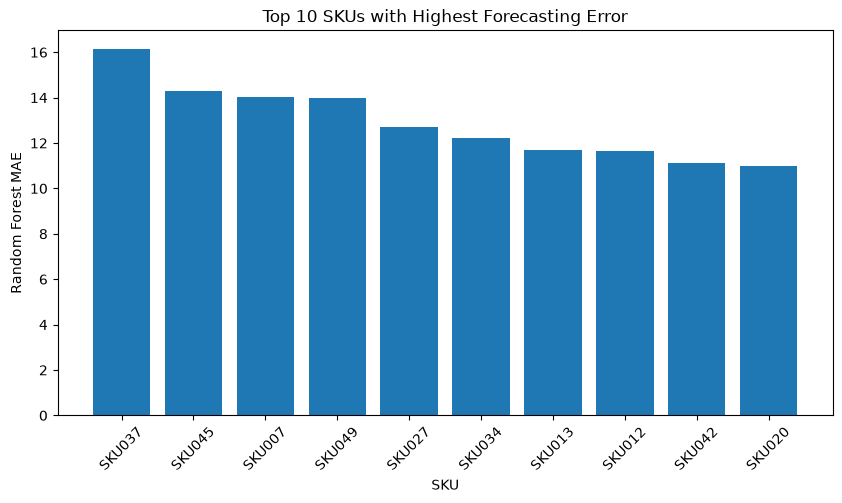

In [23]:
top_10_skus = sku_performance.sort_values(
    by="RF_MAE",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(top_10_skus["SKU"], top_10_skus["RF_MAE"])

plt.title("Top 10 SKUs with Highest Forecasting Error")
plt.xlabel("SKU")
plt.ylabel("Random Forest MAE")
plt.xticks(rotation=45)

plt.show()

### SKU-Level Forecasting Error Analysis

The top 10 SKUs with the highest Random Forest MAE were identified to understand product-level forecasting performance.

* SKU037 recorded the highest MAE of approximately 16.15 units.
* SKU045, SKU007, and SKU049 also showed relatively high prediction errors.
* Forecasting performance varies across products.
* These SKUs should be examined further before making inventory recommendations.

The analysis helps identify products that may require additional forecasting attention.


In [24]:
sku_wape = prediction_results.groupby("SKU").apply(
    lambda group: (
        group["RF_Absolute_Error"].sum()
        / group["Units_Sold"].sum()
    ) * 100
).reset_index(name="RF_WAPE")

sku_wape.head(10)

,SKU,RF_WAPE
0,SKU001,7.617934
1,SKU002,13.190141
2,SKU003,16.071078
3,SKU004,17.512821
4,SKU005,5.964058
5,SKU006,14.552863
6,SKU007,9.285635
7,SKU008,9.601485
8,SKU009,16.320755
9,SKU010,7.845714


In [25]:
sku_wape.sort_values(
    by="RF_WAPE",
    ascending=False
).head(10)

,SKU,RF_WAPE
24,SKU025,42.848649
10,SKU011,27.858491
14,SKU015,20.854478
47,SKU048,20.616747
3,SKU004,17.512821
29,SKU030,16.854651
35,SKU036,16.428161
8,SKU009,16.320755
2,SKU003,16.071078
38,SKU039,15.560748


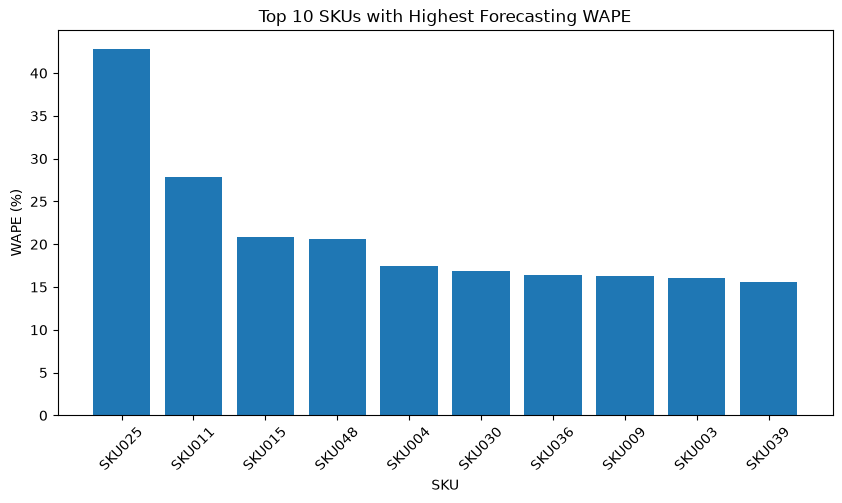

In [26]:
top_10_wape = sku_wape.sort_values(
    by="RF_WAPE",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))

plt.bar(top_10_wape["SKU"], top_10_wape["RF_WAPE"])

plt.title("Top 10 SKUs with Highest Forecasting WAPE")
plt.xlabel("SKU")
plt.ylabel("WAPE (%)")
plt.xticks(rotation=45)

plt.show()

## SKU-Level Forecasting Performance Analysis

### MAE Analysis

* SKU037 recorded the highest Random Forest MAE of approximately 16.15 units.
* SKU045, SKU007, and SKU049 also showed relatively high absolute errors.

### WAPE Analysis

* SKU025 recorded the highest Random Forest WAPE of approximately 42.85%.
* SKU011 recorded 27.86%.
* SKU015 and SKU048 also showed WAPE values above 20%.

### Business Interpretation

MAE measures forecasting error in units, while WAPE measures error relative to actual demand.

SKU-level analysis helps identify products that need further forecasting investigation. These results will later be combined with inventory information to assess stock risk.

### Evaluation Limitation

The current evaluation uses rolling one-week-ahead predictions with actual demand available for previous weeks. A separate rolling-origin backtest is required to assess performance across multiple forecast origins.

### Conclusion

Random Forest achieved lower overall MAE and WAPE than the Seasonal Naive baseline on the current test set. However, performance varies by SKU, so further validation is required before operational use.
